In [ ]:
# TODO: FIX, IMAGES WITH BIDS 0.0/0.0 CREATE 0.5/0.5 IMAGES INSTEAD OF BASE PROMPT
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

INPUT_DIR = "../alignment/alignment_2_agent"
OUTPUT_DIR = "results/2_agent/welfare"  # Output directory for generated images

# Sampling configuration
NUM_SAMPLES_PER_COMBINATION = 20  # Number of times to sample each prompt-bid combination
NUM_PROMPTS = 25
SWEEP_VALUES = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

'''
for k samples for each prompt, generate the following images:
1. heatmap for welfare improvement over the baseline VCG
2. show base_alignment remains high
3. regret from truthful bidding?
'''

'\nfor k samples for each prompt, generate the following images:\n1. heatmap for welfare improvement over the baseline VCG\n2. show base_alignment remains high\n3. regret from truthful bidding?\n'

In [3]:
data = {"prompt": [], "sample": [], "quality_score": [], "bid_1": [], "bid_2": [], "base_alignment": [], "agent1_alignment": [], "agent2_alignment": []}
for prompt_num in range(NUM_PROMPTS):
    for sample_num in range(NUM_SAMPLES_PER_COMBINATION):
        for b1 in SWEEP_VALUES:
            filename = f"alignment_p{prompt_num:03}_b{b1:.2f}_{1-b1:.2f}_s{sample_num:02}.json"
            json_path = os.path.join(INPUT_DIR, filename)
            with open(json_path, 'r') as file:
                sample_data = json.load(file)
                data['prompt'].append(sample_data['metadata']['prompt_index'])
                data['sample'].append(sample_data['metadata']['sample_index'])
                data['quality_score'].append(sample_data['quality_assessment']['clip_quality'])
                data['bid_1'].append(sample_data['metadata']['bids'][0])
                data['bid_2'].append(sample_data['metadata']['bids'][1])
                data['base_alignment'].append(sample_data['alignment_scores']['base_alignment'])
                data['agent1_alignment'].append(sample_data['alignment_scores']['agent1_alignment'])
                data['agent2_alignment'].append(sample_data['alignment_scores']['agent2_alignment'])
# base alignments
for prompt_num in range(NUM_PROMPTS):
    for sample_num in range(NUM_SAMPLES_PER_COMBINATION):
        filename = f"alignment_p{prompt_num:03}_b0.00_0.00_s{sample_num:02}.json"
        json_path = os.path.join(INPUT_DIR, filename)
        with open(json_path, 'r') as file:
            sample_data = json.load(file)
            data['prompt'].append(sample_data['metadata']['prompt_index'])
            data['sample'].append(sample_data['metadata']['sample_index'])
            data['quality_score'].append(sample_data['quality_assessment']['clip_quality'])
            data['bid_1'].append(sample_data['metadata']['bids'][0])
            data['bid_2'].append(sample_data['metadata']['bids'][1])
            data['base_alignment'].append(sample_data['alignment_scores']['base_alignment'])
            data['agent1_alignment'].append(sample_data['alignment_scores']['agent1_alignment'])
            data['agent2_alignment'].append(sample_data['alignment_scores']['agent2_alignment'])

In [4]:
df = pd.DataFrame.from_dict(data)
df_cleaned = df[~df['prompt'].isin([14, 24, 16, 12, 5])]

In [18]:
def plot_base_alignment(df):
    base_df = df[(df['bid_1']==0) & (df['bid_2']==0)]
    df = df[~df.index.isin(base_prompt_df.index)]
    
    agent1_stats = df.groupby('bid_1')['base_alignment'].agg(['mean', 'std', 'count']).reset_index()
    agent1_stats['se'] = agent1_stats['std'] / np.sqrt(agent1_stats['count'])
   
    plt.style.use('default')  # White background
    fig, ax = plt.subplots(figsize=(10, 8), facecolor='white')
    ax.set_facecolor('white')
    
    # Plot Agent 1 alignment vs bid_1
    ax.plot(agent1_stats['bid_1'], agent1_stats['mean'], 'o-', linewidth=2, markersize=8, 
            color='purple', markeredgecolor='navy', markeredgewidth=1)
    ax.fill_between(agent1_stats['bid_1'], 
                    agent1_stats['mean'] - agent1_stats['se'],
                    agent1_stats['mean'] + agent1_stats['se'],
                    alpha=0.3, color='purple')
    
    ax.tick_params(axis='both', labelsize=14)
    ax.set_xlabel('Agent 1 Bid Value', fontsize=15)
    ax.set_ylabel('Average Base Alignment ± SE', fontsize=15)
    
    ax.axhline(y=base_df['base_alignment'].mean(), linestyle=':', color='gray')
    
    ax.set_title(f'Base Prompt Alignment Across Bid Values', fontsize=16, pad=20)

    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
#     ax.set_ylim(0.475, 0.525)
    
    plt.tight_layout()
    return plt

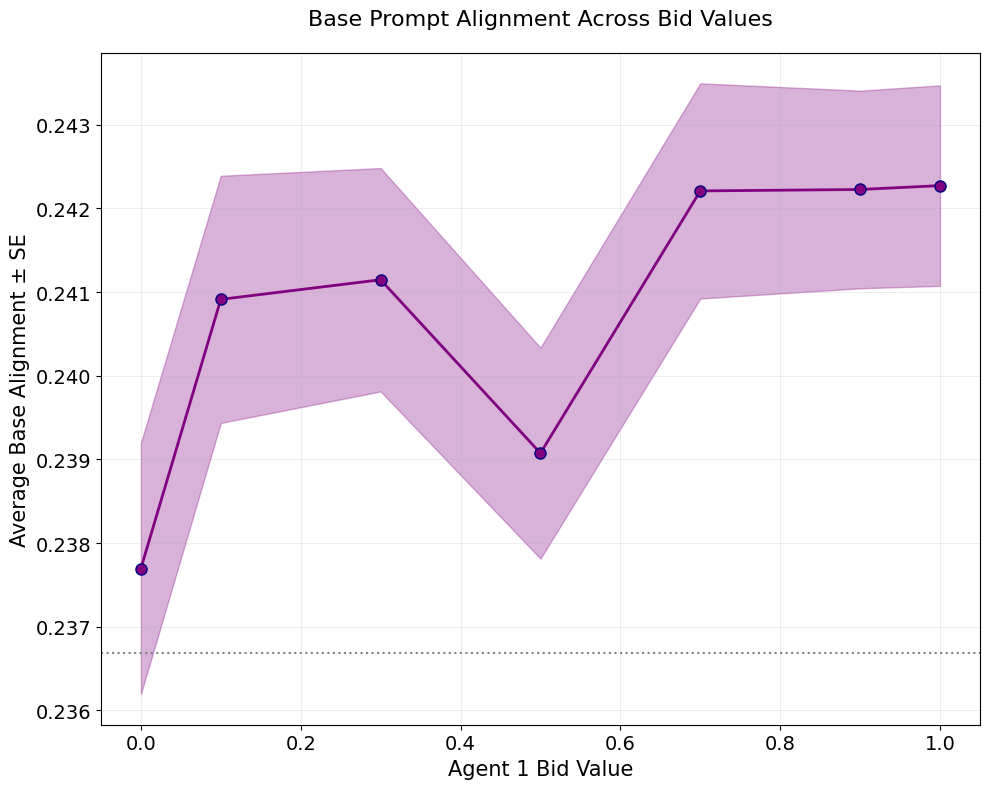

In [19]:
# Plot bid monotonicity
plt = plot_base_alignment(df_cleaned)
# plt.savefig(f'../results/2_agents/bid_monotonicity.png', dpi=300, bbox_inches='tight')
plt.show()